<a href="https://colab.research.google.com/github/MoSkibidi/Signal_Processing_Project_2025/blob/main/Project_Denoise_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.) อ่านไฟล์เสียงและพล็อตกราฟ Waveform

ในบล๊อคแรกจะประกอบไปด้วยการ `import lib`
การอ่านและแสดงข้อมูลพื้นฐานของไฟล์เสียง โดยก่อนจะพล็อตกราฟนิสิตได้ทำการ
`Normalize Data` ให้อยู่ในช่วง 0-1
ไม่ได้เห็นความแตกต่างชัดเจนในบล๊อคนี้แต่นิสิตทำไว้เพื่อเทียบกับไฟล์หลังผ่านการ
กรองภายหลัง


Original datatype: int16
Number of channels: 1
Frame rate: 11025
Sample width (bytes): 2
Number of frames: 165691


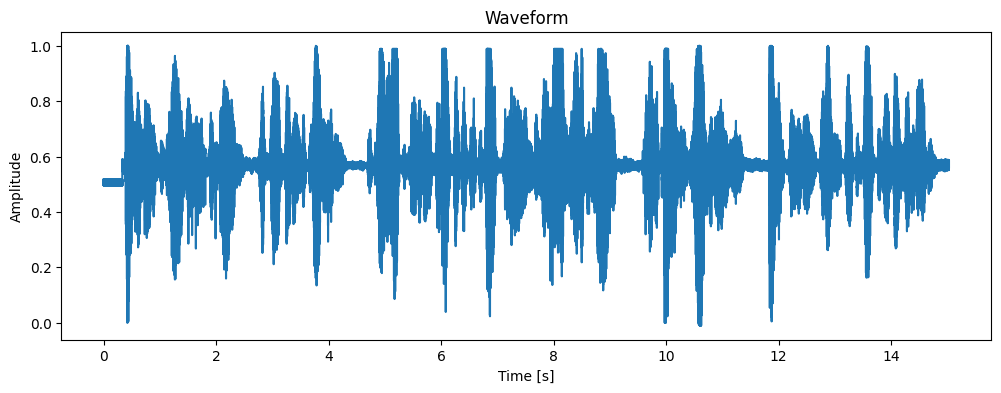

In [ ]:
import matplotlib.pyplot as plt
from scipy.io import wavfile
import numpy as np
from scipy import signal
import wave

sound = "exercise_22.wav"
sr, y = wavfile.read(sound)
print("Original datatype:",y[0].dtype)
y = y.astype(np.float32) / np.max(np.abs(y)) #แปลงข้อมูลจากที่เป็น INT ให้เป็นทศนิยมเพราะฟังก์ชัน FFT เหมาะกับทศนิยม แล้วก็ scale ให้อยู่ในช่วง 1


with wave.open(sound, 'rb') as wf:
    print("Number of channels:", wf.getnchannels())
    print("Frame rate:", wf.getframerate())
    print("Sample width (bytes):", wf.getsampwidth())
    print("Number of frames:", wf.getnframes())

t = np.linspace(0, len(y)/sr, num=len(y))
plt.figure(figsize=(12, 4))
plt.plot(t, y)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.show()

#2.) แปลงและพล็อตกราฟใน Frequency Domain

นิสิตทำการสร้างฟังก์ชันเพื่อแปลง ***Data*** ใน ***Time Domain*** ไป ***Freq Domain*** โดยใช้ **FFT** จากนั้นดึงแค่ค่า Real มาใช้ โดยฟังก์ชันนี้สามารถเลือกช่วงเวลาที่ต้องการให้พล็อต
กราฟเองได้
ก่อนหน้านี้นิสิตได้ทำการนำไฟล์ **mp3** มาเปิดฟังและได้ทราบว่าในช่วงเวลาประมาณ
**0-4** วินาที และ **10-15** วินาที มีเสียงจี๊ดหรือเสียงรบกวนปนอยู่ นิสิตจึงทำการพล็อตกราฟความถี่ในช่วงเวลานั้นออกมา พบว่ามีบางความถี่ที่มีค่ามากกว่าปกติ `(2500 ,4500 Hz) `

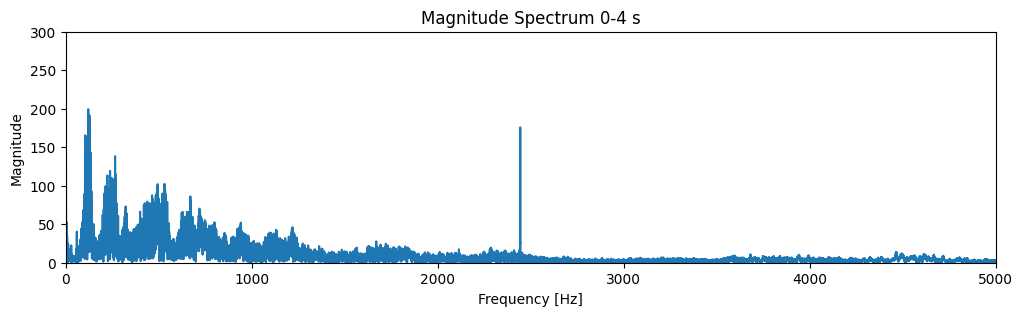

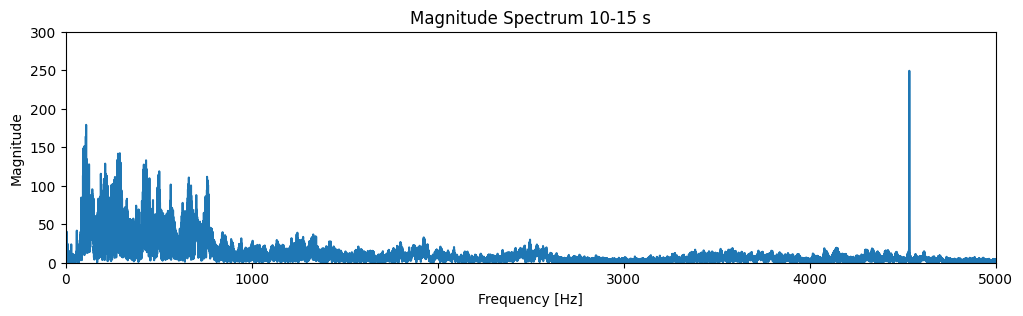

In [ ]:
def plot_fft_segment(sig, sr, start, end): #ทำฟังก์ชันเพื่อซูมดู Magnitude Start = เวลาเริ่ม,  end = เวลาจบ
    seg = sig[int(start*sr):int(end*sr)] #scale ให้อยู่ในช่วงเวลาที่กำหนด
    N = len(seg)
    Y = np.fft.rfft(seg)  #FFT Data ให้อยู่ในรูปของฝั่ง Real เท่านั้น
    F = np.fft.rfftfreq(N, 1/sr) #สร้างแกนความถี่
    plt.figure(figsize=(12,3))
    plt.plot(F, np.abs(Y))
    plt.title(f"Magnitude Spectrum {start}-{end} s")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude")
    plt.xlim(0, 5000)
    plt.ylim(0, 300)
    plt.show()

plot_fft_segment(y, sr, 0, 4)
plot_fft_segment(y, sr, 10, 15)


#3.) สร้าง Spectogram เพื่อยืนยันความถี่ที่ผิดปกติ

ก่อนนำค่าไปพล็อตนิสิตได้ทำการ `Scale` ข้อมูลให้อยู่ในช่วง ***dB*** เพื่อกันไม่ให้ข้อมูลกระจายมากเกินไป จากนั้นนิสิตทำการพล็อตกราฟ `Spectogram `เพื่อยืนยันว่าความถี่รบกวนนั้นตรงกับที่พบใน `บล็อค 2` หรือไม่ โดยหากสังเกตจากกราฟจะพบว่าในย่านความถี่ `2500 ,4500 Hz` นั้นมีเส้นซึ่งแสดงถึงความถี่ที่มีความเข้มสูงผิดปกติในช่วงเวลาที่คาดเดาไว้พอดี

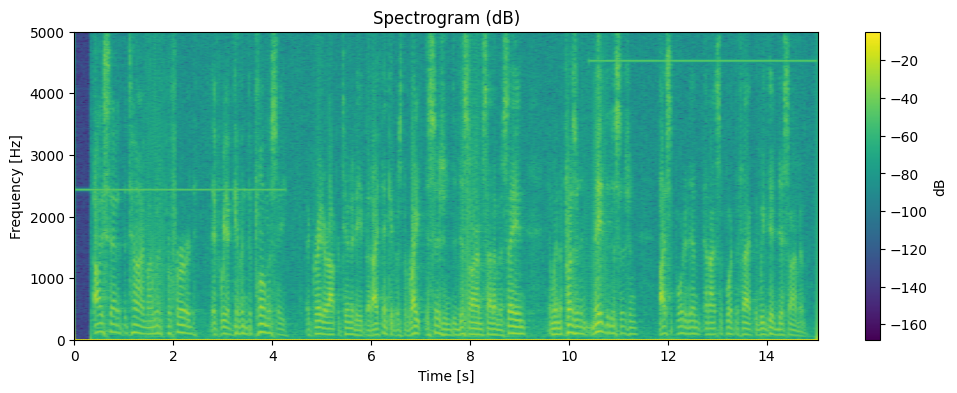

In [ ]:
f, t, Zxx = signal.stft(y, fs=sr, nperseg=1024) #แบ่งค่า
plt.figure(figsize=(12, 4))
plt.pcolormesh(t, f, 20*np.log10(np.abs(Zxx)+1e-12), shading='gouraud') #Scale เป็น dB
plt.title("Spectrogram (dB)")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")
plt.colorbar(label="dB")
plt.ylim(0, 5000)  # zoom เฉพาะ 0–5 kHz
plt.show()

#4.) Filter สัญญาณด้วย Notch
นิสิตทำการ Normalize Data ก่อนเพื่อนำไปเข้าฟังก์ชัน `notch_with_depth(y, sr, freqs, BW, att_db)` ซึ่ง Input จะมีดังนี้

y = Data ที่ถูก Normalize แล้ว

sr = Sampling Rate

freqs = ตำแหน่งกึ่งกลางของความถี่ที่ต้องการ Denoise

BW = ขนาด Bandwidth ที่ต้องการ Denoise

att_db = ความดังที่ต้องการลดลง (dB)

โดยนิสิตได้ทำการใส่ `freqs` ตามตำแหน่งที่พบความถี่ที่ผิดปกติ จากนั้นกำหนด
`Bandwidth` กับ `att_db` ให้เหมาะสม ไม่มากจนส่งผลให้สัญญาณเกิดการเปลี่ยนแปลงมากจนเกินไป หลังจากนั้นนิสิตได้ทำการจำลองกราฟ ก่อน/หลัง ทำการ `Filter` ออกมาดังรูปเพื่อให้เห็นความแตกต่าง จากนั้นก็ทำการแปลงและเซฟไฟล์หลังทำการ Filter เสร็จ


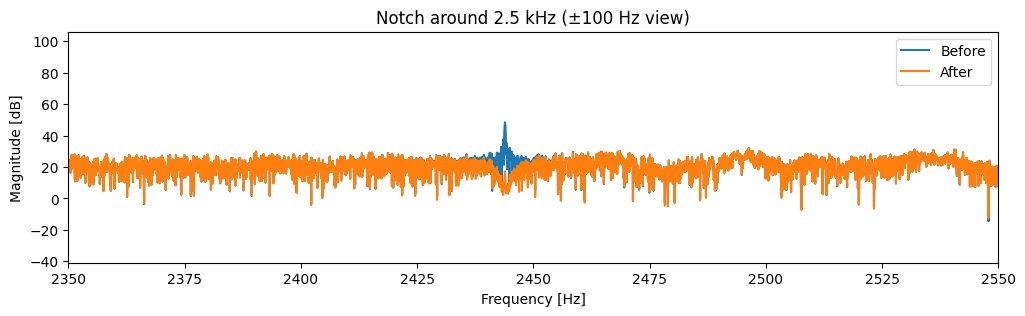

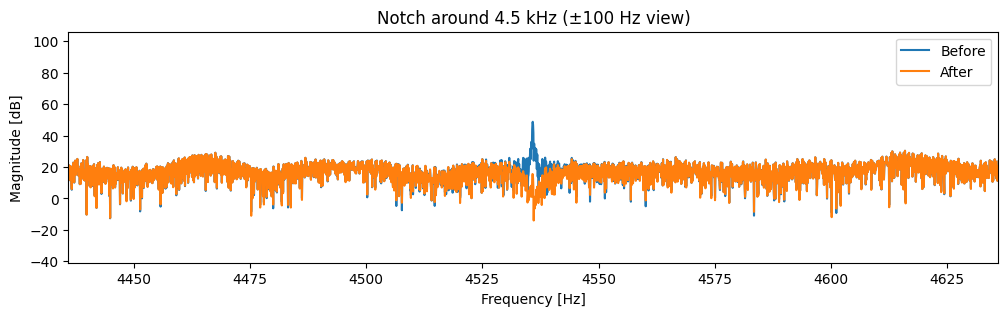

Saved: Denoise_sound.wav


In [ ]:

y /= (np.max(np.abs(y)) + 1e-12) #ทำการ Normalize ใหม่คล้ายๆเดิมแต่ + 1e-12 ไปกันค่า = 0 เดี๋ยว error

#หาสัมประสิทธ์เพื่อมาทำ Bandstop
def notch_with_depth(y, sr, freqs, BW, att_db):
    # ออกแบบ notch ทั้งหมด
    sos = np.vstack([signal.tf2sos(*signal.iirnotch(f, f/BW, fs=sr)) for f in freqs])
    y_notch = signal.sosfiltfilt(sos, y)

    # คำนวณสัดส่วนผสมจาก dB เป้าหมาย
    m = 1.0 - 10**(-att_db/20.0)
    y_out = (1-m)*y + m*y_notch
    return y_out

centers = [2444.0, 4536.0] #Bandstop โดยมีกำหนด Center และ Bandwidth ที่เหมาะสม
BW = 5

# Filter
y_notched = notch_with_depth(y, sr, centers, BW, 35)


def mag_spectrum_db(sig, sr): #ฟังก์ชันคืนค่า spectrum(dB)
    Y = np.fft.rfft(sig)
    F = np.fft.rfftfreq(len(sig), 1/sr)
    M = 20*np.log10(np.abs(Y) + 1e-12)
    return F, M

F0, M0 = mag_spectrum_db(y, sr)
F1, M1 = mag_spectrum_db(y_notched, sr)

def zoom_plot(Fa, Ma, Fb, Mb, lo, hi, title): #พลอตกราฟเป็นช่วงที่กำหนด
    plt.figure(figsize=(12, 3))
    plt.plot(Fa, Ma, label="Before")
    plt.plot(Fb, Mb, label="After")
    plt.xlim(lo, hi)
    plt.xlabel("Frequency [Hz]"); plt.ylabel("Magnitude [dB]")
    plt.title(title); plt.legend(); plt.show()

r = 100 #2*r = bandwidth ที่ต้องการแสดง
zoom_plot(F0, M0, F1, M1, 2450-r, 2450+r, f"Notch around 2.5 kHz (±{r} Hz view)")
zoom_plot(F0, M0, F1, M1, 4536-r, 4536+r, f"Notch around 4.5 kHz (±{r} Hz view)")

file_name = "Denoise_sound.wav" #โหลดไฟล์
wavfile.write(file_name,
              sr, np.int16(np.clip(y_notched, -1, 1)*32767)) #แปลงไฟล์กลับไปเป็น int16 ก่อนโหลด
print("Saved:", file_name)


#5.) สร้างกราฟหลังการ Filter เพื่อเปรียบเทียบ
ในภาพเปรียบเทียบ `Waveform` สังเกตได้ว่า `Amplitude` นั้นแตกต่างกันเพียงนิดเดียวหลังจาก `Filter` ความถี่บางช่วงออก จะเห็นได้ชัดกว่าในภาพที่ซูมเข้า และในภาพต่อไปแสดงกราฟ `Spectrogram` สังเกตได้ว่าเส้นสว่างๆที่เคยเห็นได้ชัดในบางความถี่นั้นกลมกลืนไปกับความถี่อื่นๆแล้ว แสดงว่าการทำ `Filter` ในข้อ 4 นั้นได้ผล


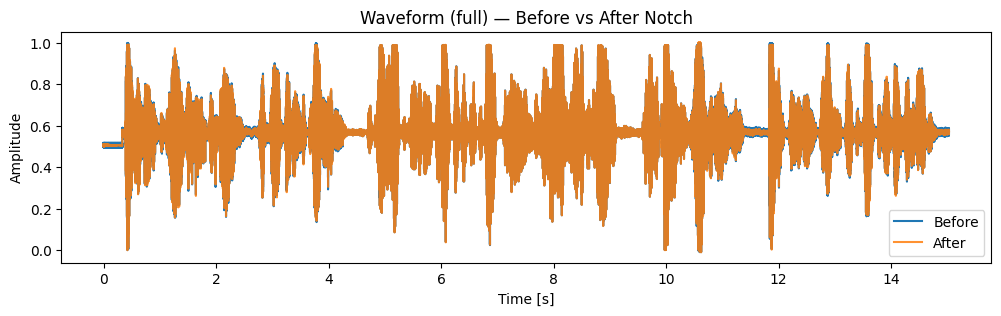

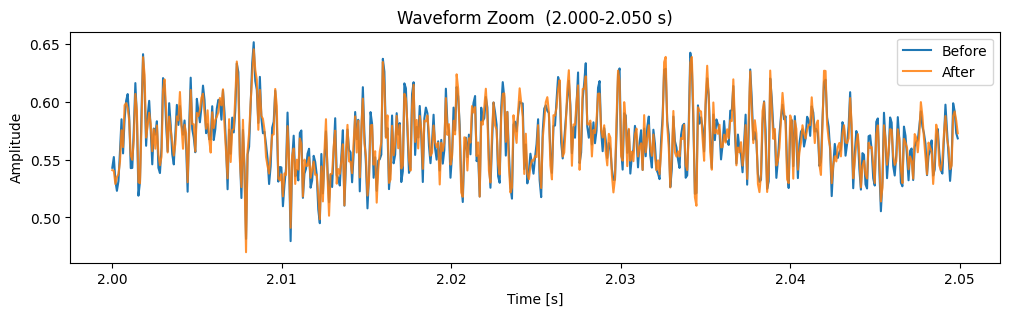

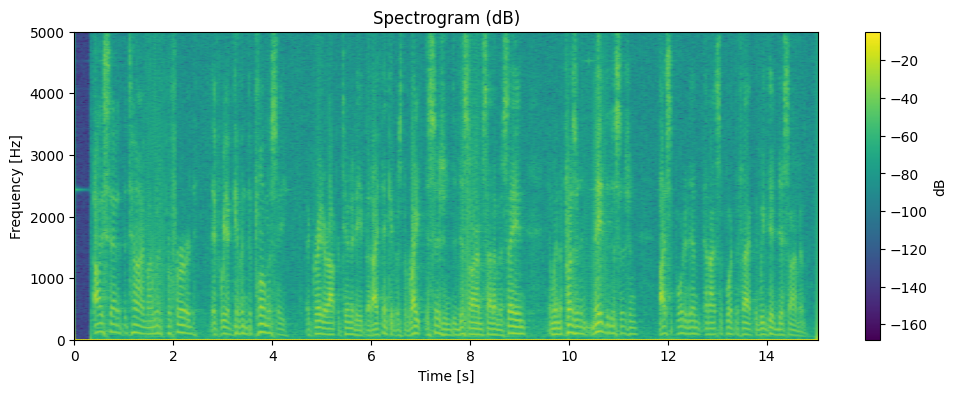

In [ ]:
t = np.arange(len(y)) / sr #ทำกราฟเพื่อเทียบ Time Domain ก่อน-หลังทำการ Filter
plt.figure(figsize=(12, 3))
plt.plot(t, y, label="Before")
plt.plot(t, y_notched, label="After", alpha=0.85)
plt.xlabel("Time [s]"); plt.ylabel("Amplitude")
plt.title("Waveform (full) — Before vs After Notch")
plt.legend(); plt.show()

def plot_waveform_zoom(sr, y_before, y_after, t_start, t_end, title="Waveform Zoom"):
    n = min(len(y_before), len(y_after))
    i0 = max(0, int(t_start * sr))
    i1 = min(n, int(t_end * sr))

    t_win = np.arange(i0, i1) / sr
    plt.figure(figsize=(12, 3))
    plt.plot(t_win, y_before[i0:i1], label="Before")
    plt.plot(t_win, y_after[i0:i1], label="After", alpha=0.85)
    plt.xlabel("Time [s]"); plt.ylabel("Amplitude")
    plt.title(f"{title}  ({t_start:.3f}-{t_end:.3f} s)")
    plt.legend(); plt.show()

plot_waveform_zoom(sr, y, y_notched, t_start=2.00, t_end=2.05, title="Waveform Zoom")

#Spectrogram
f, t, Zxx = signal.stft(y_notched, fs=sr, nperseg=1024) #แบ่งค่า
plt.figure(figsize=(12, 4))
plt.pcolormesh(t, f, 20*np.log10(np.abs(Zxx)+1e-12), shading='gouraud')
plt.title("Spectrogram (dB)")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")
plt.colorbar(label="dB")
plt.ylim(0, 5000)  # zoom เฉพาะ 0–5 kHz
plt.show()


#6.)คำนวณ MAE
ในขั้นตอนสุดท้ายจะทำการคำนวณความแตกต่างของ `Data` โดยจะใช้สูตร `MAE` ตามนี้ค่า่ที่ได้ออกมาจะเป็นค่าที่ `Normalize` อยู่แล้ว

In [ ]:
def mae(y_true, y_filt):
    n = min(len(y_true), len(y_filt))
    a = y_true[:n].astype(np.float64)   #ปรับให้แน่ใจว่าเป็น Dtype เดียวกัน
    b = y_filt[:n].astype(np.float64)
    return float(np.mean(np.abs(a - b)))

mae_value = mae(y, y_notched)
mae_norm_pct = mae_value * 100.0   # %  full-scale
print("MAE:", mae_value)
print("MAE (Normalize):", mae_norm_pct, "%")

MAE: 0.004296398230255875
MAE (Normalize): 0.4296398230255875 %


#7.)สรุปผลการทดลอง
จากการทดลองนี้ถือว่าประสบผลสำเร็จเนื่องจากำฟล์เสียงหลังทำการทดลองนั้นไม่มีเสียงรบกวนเหลือแล้ว โดยในการทดลองนี้ใช้ส่วนขยายของ `Python` ที่ชื่อว่า `Notch` ซึ่งทำหน้าที่คล้าย `Bandstop` เป็นตัวกรองเสียงรบกวน

โดยการที่จะหาเสียงรบกวนได้ว่าอยู่ในช่วงเวลาไหน หรือความถี่ไหนก็ต้องอาศัยการทดสอบด้วยตัวเองไม่ว่าจะเป็นการเปิดฟังเสียง การสร้างกราฟเวลา หรือการสร้างกราฟความถี่โดยท้ายที่สุดแล้วนิสิตก็ได้พบว่าเสียงรบกวนนั้นอยู่ในช่วงไหน และความถี่เท่าไหร่บ้างจากนั้นจึงทำการกรองเสียงรบกวน

หลังจากทำการทำการกรองเสียงรบกวนเรียบร้อยแล้ว เพื่อความถูกต้องนิสิตต้องวนกลับไปทำขั้นตอนเดิมๆเช่น ฟังเสียง สร้างกราฟเวลา และกราฟความถี่ เพื่อตรวจสอบความแตกต่างหลังกรองความถี่เรียบร้อย และสุดท้ายก็คำนวณหาค่า `MAE` ซึ่งผลก็ออกมาเป็นที่น่าพึงพอใจ
